# Research Methods <br>UHH - Knowledge Technology Research Group - WiSe 2025/2026
## Assignment #6 - Bayesian Inference & Hypothesis Testing

***
### Group: A
### Names of members:  Niloufar Baba Ahmadi, Narges Baba Ahmadi, Alexandra Helen Hooser

***

### Instructions:

Please answer the questions below. Copy this notebook and enter your answers underneath each task description, inserting cells as needed. You may use a combination of [python 3](https://www.python.org), [markdown](http://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html), and [LaTex](https://towardsdatascience.com/write-markdown-latex-in-the-jupyter-notebook-10985edb91fd) to formulate your responses. In order to successfully complete the assignment, you will need the lecture material provided in the [RM moodle course](https://lernen.min.uni-hamburg.de/course/view.php?id=5728), especially L10 & L11.

**Make sure to use only a copy of this notebook for your answers instead of a new/blank notebook.**

### Grading Criteria:

In order to successfully pass this assignment, you will need **at least a total of 70 points out of 100 points**, and every task has to be tackled.

### Submission:

<span style="color: red">**Please note that the deadline for the submission of this assignment falls on a Monday!**</span>

Please upload the following two files **until Monday, January 19, 2026, 20:00 CET (Germany)** together in a .zip archive in moodle:
1. a (single) copy of this jupyter notebook containing your answers for all tasks (file extension: .ipynb)
2. an [exported PDF document](https://jupyterlab.readthedocs.io/en/stable/user/export.html) of the jupyter notebook (file extension: .pdf)

### Presentation:

Make sure that each (!) group member takes part in solving this assignment and is prepared to answer questions and/or present solutions from your submitted notebook during our assignment revision meeting scheduled for **Wednesday, January 21, 2026, 10:00 - 13:00 CET (Germany)**.

### File Naming:

Add the group letter to the file name prior to submission. For example, if your group letter is "A" (see group selection in moodle), you would use the following filename:
1. RM_A06_Group_A.ipynb
2. RM_A06_Group_A.pdf

***
***

In [1]:
import matplotlib.pyplot as plt
import itertools
import math

#### Task 1 **[40 points] Bayes Parameter Estimation**

Please answer each of the following three questions with step-by-step calculations **and thorough answers/explanations**, using python code and suitable plots.
1. **Scenario:** You are an astronomer investigating the prevalence of exoplanets around a particular type of star in a nearby galaxy cluster. From extensive surveys, you know that approximately 15% of these stars host an exoplanet. Your telescope’s detection system is quite sensitive: if a star truly has an exoplanet, the system will indicate a detection 90% of the time (true positive rate). However, the system still produces a small fraction of false positives: 5% of stars without exoplanets are incorrectly flagged as having one. Now suppose you receive a detection signal from one star under observation.

    **Question:** Using Bayes’ Theorem, calculate the probability that this star truly hosts an exoplanet, given that the telescope indicated a detection.<br><br>



#### Task 1.1

We want the probability that the star truly hosts an exoplanet after we observe a detection signal. We define:

* P: "star has an exoplanet" (hypothesis)
* $\neg$ P: “star has no exoplanet”
* D: “telescope reports a detection” (data)

As per the given information we have:

* Prior prevalence: $p(P)=0.15$, so $p(\neg P)=0.85$
* True positive rate: $p(D\mid P)=0.90$
* False positive rate: $p(D\mid \neg P)=0.05$

Bayes' theorem connects prior, likelihood, and posterior:

$$
p(P\mid D)=\frac{p(P),p(D\mid P)}{p(D)}
$$

We compute $p(D)$:
$$
p(D)=p(P)p(D\mid P)+p(\neg P)p(D\mid \neg P)
$$
$$
p(D)=0.15\cdot0.90 + 0.85\cdot0.05 = 0.135 + 0.0425 = 0.1775
$$

Therefore, we have:

$$
p(P\mid D)=\frac{0.15\cdot 0.90}{0.1775}=\frac{0.135}{0.1775}\approx 0.7606
$$

So, given a detection, there is about a 76.1% chance the star truly has an exoplanet.

The bar plot visualizes the Bayesian belief update (prior to posterior), the prior is what we believe before seeing data so it shows the baseline belief, and the posterior is what we believe after seeing the data.

Posterior p(planet | detection) = 0.760563


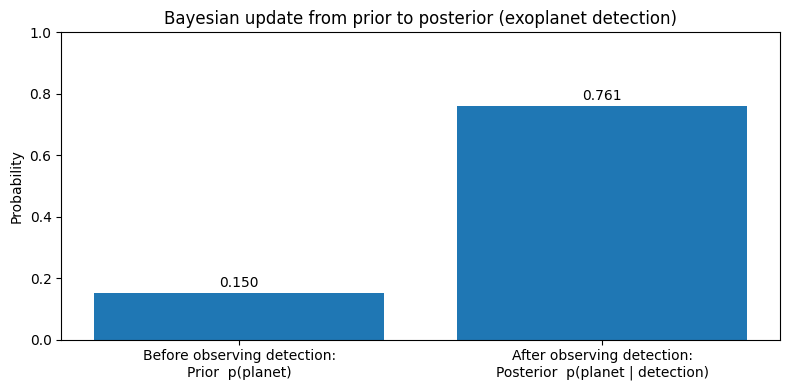

In [ ]:
# Given values
p_planet = 0.15
p_det_given_planet = 0.90
p_det_given_no_planet = 0.05
p_no_planet = 1 - p_planet

numerator = p_planet * p_det_given_planet
p_det = numerator + p_no_planet * p_det_given_no_planet
p_planet_given_det = numerator / p_det

print(f"Posterior p(planet | detection) = {p_planet_given_det:.6f}")

labels = [
    "Before observing detection:\nPrior  p(planet)",
    "After observing detection:\nPosterior  p(planet | detection)"
]
values = [p_planet, p_planet_given_det]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, values)
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Bayesian update from prior to posterior (exoplanet detection)")

for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()


2. **Scenario:** You have two identical-looking boxes on your desk, each containing small toy blocks of different colors. Specifically:

    - Box A has 4 red blocks and 6 green blocks.<br>
    - Box B has 7 red blocks and 3 green blocks.<br><br>

    You randomly choose one box (each with 50% probability) and then randomly draw one block from that box.

    **Questions:** <br>
    (a) What is the probability of drawing a red block?<br>
    (b) Given that you drew a red block, what is the probability that it came from Box B?<br><br>



#### Task 1.2

We have two boxes:

* Box A: 4 red, 6 green  $\Rightarrow\ p(R\mid A)=\frac{4}{10}=0.4$
* Box B: 7 red, 3 green  $\Rightarrow\ p(R\mid B)=\frac{7}{10}=0.7$

We choose a box randomly $\Rightarrow\ p(A)=p(B)=0.5$

##### (a) Probability of drawing a red block $\Rightarrow\ p(R)$

Using the law of total probability:
$$
p(R)=p(A)p(R\mid A)+p(B)p(R\mid B)
$$
$$
p(R)=0.5(0.4)+0.5(0.7)=0.2+0.35=0.55
$$

##### (b) Given red, probability it came from Box B $\Rightarrow\ p(B\mid R)$

Use Bayes’ theorem:
$$
p(B\mid R)=\frac{p(B)p(R\mid B)}{p(R)}
$$
$$
p(B\mid R)=\frac{0.5(0.7)}{0.55}=\frac{0.35}{0.55}\approx 0.636
$$

The bar plot summarizes the full reasoning chain. The first two bars, $P(\text{red}\mid A)$ and $P(\text{red}\mid B)$, show how likely red is in each box. The third bar $P(\text{red})$ is the overall chance of drawing red after averaging over the randomly chosen box. The last bar $P(B\mid \text{red})$ is the posterior probability that the block came from Box B after observing a red draw. We plot this to clearly show how observing “red” shifts belief toward Box B, since red is more likely in B than in A.



P(R) = 0.55
P(B|R) = 0.6363636363636362


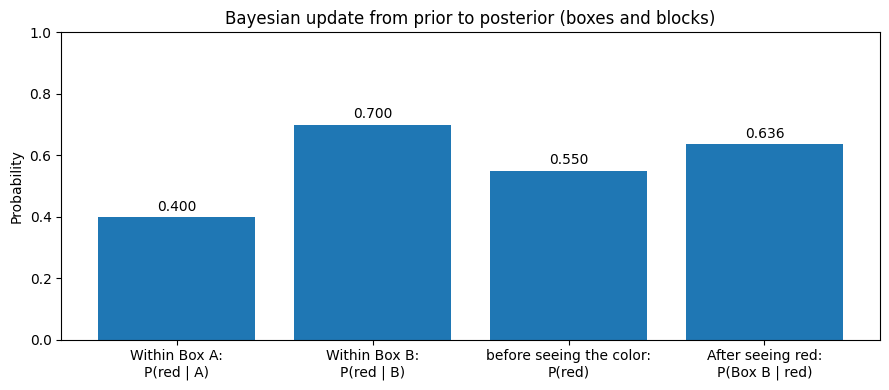

In [ ]:
# Given values
pA = 0.5
pB = 0.5
pR_given_A = 4/10
pR_given_B = 7/10

pR = pA*pR_given_A + pB*pR_given_B
pB_given_R = (pB*pR_given_B) / pR

print("P(R) =", pR)
print("P(B|R) =", pB_given_R)

labels = [
    "Within Box A:\nP(red | A)",
    "Within Box B:\nP(red | B)",
    "before seeing the color:\nP(red)",
    "After seeing red:\nP(Box B | red)"
]
values = [pR_given_A, pR_given_B, pR, pB_given_R]

plt.figure(figsize=(9, 4))
bars = plt.bar(labels, values)
plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Bayesian update from prior to posterior (boxes and blocks)")

for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()


3. **Scenario:** You are playing a game of Dungeons & Dragons and facing a main villain controlled by the Dungeon Master (DM). This villain always makes attacks with two weapons, but you only observe the total of the damage rolls (the sum of both dice) on each attack. You know that each weapon die must be one of the four types d6, d8, d10 or d12 (dX = X-sided die) and there is no duplication of weapons—meaning the two dice must be different (for example, the pair could be a d6 and d8, but not two d6s). Your working hypothesis is that the DM is using a d8 and a d10.<br><br>
    **Question:** What is the probability that your hypothesis is correct, given the most recent six total damage values (the last six attack rolls) have been [6, 12, 14, 11, 9, 10]?

#### Task 1.3

We treat each possible pair of different dice as a hypothesis:

$$
H \in {(6,8),(6,10),(6,12),(8,10),(8,12),(10,12)}
$$

Assume a uniform prior $p(H)=1/6$. For a given pair (a,b), we compute the probability of each observed sum s:

$$
p(S=s\mid a,b)=\frac{\#\{(i,j):i+j=s\}}{ab}
$$

Assuming attacks are independent given the dice, the likelihood of the full dataset D=[6,12,14,11,9,10] is:

$$
p(D\mid a,b)=\prod_{k} p(S=d_k\mid a,b)
$$

Then we compute the posterior over pairs by Bayes' rule:

$$
p(a,b\mid D)\propto p(a,b),p(D\mid a,b)
$$

and normalize so the posterior sums to 1.

The bar plot (posterior over dice pairs) shows the final posterior probability of each candidate dice pair after using all six observed sums. The tallest bars are the most plausible pairs given the data.

The line plot (sequential updating) shows how those probabilities evolve after each observed attack. This visualizes Bayesian updating: each new sum nudges the posterior up or down depending on how likely that sum is under each pair.

After observing the six total damage sums [6,12,14,11,9,10], the bar chart shows the final posterior probability for each possible dice pair: the two most supported candidates are d6+d10 $(\approx 0.255)$ and d8+d10 $(\approx 0.251)$, meaning our hypothesis d8+d10 is plausible but not clearly dominant. The line plot shows the same idea over time: as each new sum is added, the posterior for each candidate pair shifts up or down depending on how well that pair explains the observed sums, and by the end the probabilities concentrate most on those two pairs while others (like d10+d12) remain less likely.


Posterior P(d8+d10 | data) = 0.2512448652912797
d6+d8: 0.1082
d6+d10: 0.2552
d6+d12: 0.1710
d8+d10: 0.2512
d8+d12: 0.1346
d10+d12: 0.0798


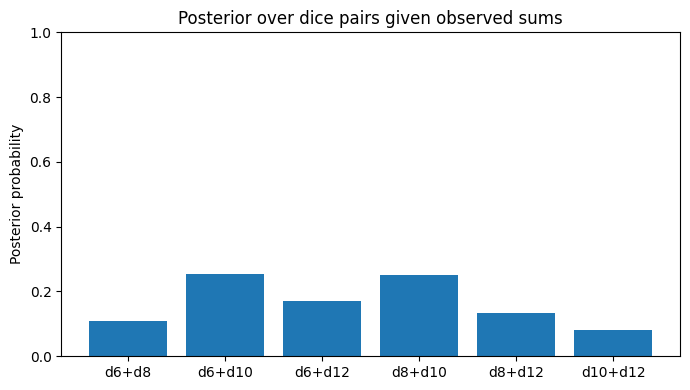

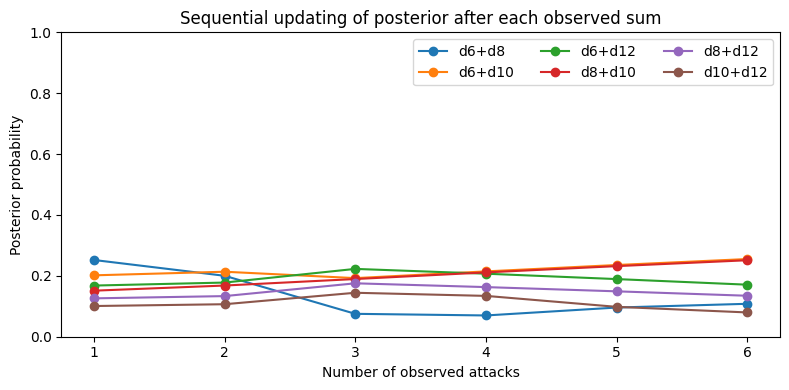

In [ ]:
dice = [6, 8, 10, 12]
pairs = list(itertools.combinations(dice, 2))  # 6 hypotheses
data = [6, 12, 14, 11, 9, 10]

def p_sum(s, a, b):
    count = 0
    for i in range(1, a + 1):
        j = s - i
        if 1 <= j <= b:
            count += 1
    return count / (a * b)

def log_likelihood(data, a, b):
    ll = 0.0
    for s in data:
        p = p_sum(s, a, b)
        if p == 0:
            return float("-inf")
        ll += math.log(p)
    return ll

prior = {pair: 1/len(pairs) for pair in pairs}
log_unnorm = {pair: math.log(prior[pair]) + log_likelihood(data, *pair) for pair in pairs}

max_log = max(log_unnorm.values())
unnorm = {pair: math.exp(log_unnorm[pair] - max_log) for pair in pairs}
Z = sum(unnorm.values())
posterior = {pair: unnorm[pair] / Z for pair in pairs}

hypothesis = (8, 10)
print("Posterior P(d8+d10 | data) =", posterior[hypothesis])

for pair in pairs:
    print(f"d{pair[0]}+d{pair[1]}: {posterior[pair]:.4f}")

# Posterior over pairs
labels = [f"d{a}+d{b}" for a, b in pairs]
values = [posterior[p] for p in pairs]

plt.figure(figsize=(7, 4))
plt.bar(labels, values)
plt.ylim(0, 1)
plt.ylabel("Posterior probability")
plt.title("Posterior over dice pairs given observed sums")
plt.tight_layout()
plt.show()

# Sequential Bayesian updating
running = {pair: prior[pair] for pair in pairs}
history = {pair: [] for pair in pairs}

for obs in data:
    for pair in pairs:
        running[pair] *= p_sum(obs, *pair)
    Z = sum(running.values())
    for pair in pairs:
        running[pair] /= Z
        history[pair].append(running[pair])

plt.figure(figsize=(8, 4))
x = list(range(1, len(data) + 1))
for pair in pairs:
    plt.plot(x, history[pair], marker="o", label=f"d{pair[0]}+d{pair[1]}")
plt.ylim(0, 1)
plt.xlabel("Number of observed attacks")
plt.ylabel("Posterior probability")
plt.title("Sequential updating of posterior after each observed sum")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()


#### Task 2 **[60 points] Savage-Dickey Method**

Returning to the Dungeons & Dragons scenario from task 1.3, our goal is now to test and evaluate the hypothesis that the DM uses a combination of the two dice d8 and d10.
1. Name one uninformed and one informed prior you would pick for the upcoming hypothesis test and motivate your decision for choosing these priors.<br>


#### 2.1

* Uninformed prior: We choose $p(\theta)=1/6$ over the 6 possible dice pairs because this matches the lecture's idea of an uninformative prior being “as unrestrictive as possible” when we want an objective starting point.

* Informed prior: We choose an informative prior that assigns higher probability to larger dice combinations (e.g. d10+d12 or d8+d12) because we can reasonably use background knowledge (villains often deal higher damage). So we have something like: $p(\theta=(6,8)) = 0.05$, $p(\theta=(6,10)) = 0.10$, $p(\theta=(6,12)) = 0.15$, $p(\theta=(8,10)) = 0.20$, $p(\theta=(8,12)) = 0.20$, $p(\theta=(10,12)) = 0.30$



2. You now want to follow the Savage-Dickey method for testing your hypothesis that the DM uses the combination of d8 and d10. State $H_0$, $H_1$, $\theta$ and $\theta_0$ for this specific case.


#### 2.2

Let the parameter be the (unknown) dice pair:

* $\theta \in {(6,8),(6,10),(6,12),(8,10),(8,12),(10,12)}$

The point value we want to test:

* $\theta_0 = (8,10)$

Hypotheses:

* $H_0: \theta = (8,10)$  (DM uses d8+d10)
* $H_1: \theta \neq (8,10)$ (DM uses any other allowed pair)

3. Perform the hypothesis test following the Savage-Dickey method using the **uninformed prior** that you previously chose. Show your calculation steps in python as well as the resulting Bayes factor.<br>

#### 2.3

Using the uninformed (uniform) prior over the 6 possible dice pairs (each pair has prior probability $P=1/6$), we apply Bayes' rule by computing for each pair the likelihood $p(D\mid \theta)$ of observing the six damage sums D=[6,12,14,11,9,10], multiplying by the prior and normalizing to obtain the posterior $p(\theta\mid D)$.

Under this setup, the hypothesis $H_0:\theta=(8,10)$ increases from a prior probability $P(H_0)=0.1667$ to a posterior probability $P(H_0\mid D)=0.2512$, meaning the observed data make d8+d10 more plausible than before. In Savage–Dickey (odds) form, the Bayes factor is:

$$
BF_{01}=\frac{\text{posterior odds}}{\text{prior odds}}=\frac{0.2512/0.7488}{0.1667/0.8333}\approx 1.678
$$

the data shift the odds in favor of $H_0$ by a factor of about 1.68 relative to $H_1$ (equivalently $BF_{10}\approx 0.596)$. This constitutes weak evidence for d8+d10: it supports $H_0$ over the composite alternative but not strongly, which is also reflected by the fact that another pair (d6+d10) remains almost equally probable in the posterior (0.2552 vs. 0.2512).


In [ ]:
import itertools
import numpy as np

dice = [6, 8, 10, 12]
pairs = list(itertools.combinations(dice, 2))
data  = [6, 12, 14, 11, 9, 10]

H0 = (8, 10)  # DM uses d8 + d10

def p_sum(s, a, b):
    count = 0
    for i in range(1, a + 1):
        j = s - i
        if 1 <= j <= b:
            count += 1
    return count / (a * b)

def likelihood(data, a, b):
    p = 1.0
    for s in data:
        ps = p_sum(s, a, b)
        if ps == 0:
            return 0.0
        p *= ps
    return p

# Uninformed prior
prior = {pair: 1/len(pairs) for pair in pairs}

# Likelihoods for each pair
L = {pair: likelihood(data, *pair) for pair in pairs}

# Posterior over pairs
unnorm = {pair: prior[pair] * L[pair] for pair in pairs}
Z = sum(unnorm.values())
post = {pair: unnorm[pair] / Z for pair in pairs}

pH0_prior = prior[H0]
pH0_post  = post[H0]

prior_odds = pH0_prior / (1 - pH0_prior)
post_odds  = pH0_post  / (1 - pH0_post)

BF01 = post_odds / prior_odds  # evidence for H0 over H1
BF10 = 1 / BF01                # evidence for H1 over H0

print("=== Savage–Dickey test (uninformed prior) ===\n")
print(f"Observed sums (data): {data}")
print(f"H0: DM uses dice pair d{H0[0]} + d{H0[1]}")
print(f"H1: DM uses any other allowed pair from {pairs}\n")

print("Prior on pairs (uninformed): uniform over 6 pairs")
print(f"  P(H0) = {pH0_prior:.6f}")
print(f"  P(H1) = {1 - pH0_prior:.6f}")
print(f"  Prior odds H0:H1 = {prior_odds:.6f}\n")

print("Posterior after observing data:")
print(f"  P(H0 | D) = {pH0_post:.6f}")
print(f"  P(H1 | D) = {1 - pH0_post:.6f}")
print(f"  Posterior odds H0:H1 = {post_odds:.6f}\n")

print("Bayes factor (Savage–Dickey / odds update):")
print(f"  BF_01 = {BF01:.6f}   (evidence for H0 over H1)")
print(f"  BF_10 = {BF10:.6f}   (evidence for H1 over H0)\n")

top = sorted(post.items(), key=lambda kv: kv[1], reverse=True)
print("Top posterior dice pairs:")
for pair, p in top[:3]:
    print(f"  d{pair[0]}+d{pair[1]}: {p:.6f}")


=== Savage–Dickey test (uninformed prior) ===

Observed sums (data): [6, 12, 14, 11, 9, 10]
H0: DM uses dice pair d8 + d10
H1: DM uses any other allowed pair from [(6, 8), (6, 10), (6, 12), (8, 10), (8, 12), (10, 12)]

Prior on pairs (uninformed): uniform over 6 pairs
  P(H0) = 0.166667
  P(H1) = 0.833333
  Prior odds H0:H1 = 0.200000

Posterior after observing data:
  P(H0 | D) = 0.251245
  P(H1 | D) = 0.748755
  Posterior odds H0:H1 = 0.335550

Bayes factor (Savage–Dickey / odds update):
  BF_01 = 1.677751   (evidence for H0 over H1)
  BF_10 = 0.596036   (evidence for H1 over H0)

Top posterior dice pairs:
  d6+d10: 0.255233
  d8+d10: 0.251245
  d6+d12: 0.170954


### 2.4
4. Repeat the test, but this time using the **informed prior**. Show again intermediate steps and the resulting Bayes factor.<br>

Using the informed prior over the 6 possible dice pairs, we again apply Bayes’ rule by computing, for each pair, the likelihood 𝑝(𝐷∣𝜃) of observing the six damage sums D = [6, 12, 14, 11, 9, 10], multiplying by the informed prior probabilities, and normalizing to obtain the posterior 𝑝(𝐷∣𝜃).

Under this setup, the hypothesis H0​:θ=(8,10) starts with prior probability P(H0​)=0.2000 (reflecting our belief that 𝑑8+𝑑10 is a somewhat plausible “higher-damage” choice). After observing the data, it increases to P(H0​∣D) =0.3187, meaning the evidence makes 𝑑8+𝑑10 more plausible than it was under the prior.

In Savage–Dickey (odds) form, we compute the Bayes factor via the odds update:

$$
BF_{01}=\frac{\text{posterior odds}}{\text{prior odds}}=\frac{0.3187/0.6813}{0.2000/0.8000}\approx 1.871
$$

So the data increase the odds in favor of $H_0$ by a factor of about 1.87 relative to $H_1$ (equivalently $BF_10$ ≈0.534). This is still weak evidence for d8+d10, but it is somewhat stronger than in the uninformed-prior case.

Unlike the uninformed-prior posterior where 𝑑6+𝑑10 was essentially tied with 𝑑8+𝑑10, under the informed prior the posterior mass concentrates more clearly on d8+d10 as the most plausible pair.

This happens because the informed prior gives more weight to larger dice combinations, and when the likelihood from the data is combined with that prior preference, d8+d10 emerges as the leading candidate.

In [2]:
import itertools
import numpy as np

dice = [6, 8, 10, 12]
pairs = list(itertools.combinations(dice, 2))
data  = [6, 12, 14, 11, 9, 10]

H0 = (8, 10)  # DM uses d8 + d10

def p_sum(s, a, b):
    count = 0
    for i in range(1, a + 1):
        j = s - i
        if 1 <= j <= b:
            count += 1
    return count / (a * b)

def likelihood(data, a, b):
    p = 1.0
    for s in data:
        ps = p_sum(s, a, b)
        if ps == 0:
            return 0.0
        p *= ps
    return p

# Informed prior
prior = {
    (6, 8): 0.05,
    (6, 10): 0.10,
    (6, 12): 0.15,
    (8, 10): 0.20,  # H0
    (8, 12): 0.20,
    (10, 12): 0.30,
}

# Likelihoods for each pair
L = {pair: likelihood(data, *pair) for pair in pairs}

# Posterior over pairs
unnorm = {pair: prior[pair] * L[pair] for pair in pairs}
Z = sum(unnorm.values())
post = {pair: unnorm[pair] / Z for pair in pairs}

pH0_prior = prior[H0]
pH0_post  = post[H0]

prior_odds = pH0_prior / (1 - pH0_prior)
post_odds  = pH0_post  / (1 - pH0_post)

BF01 = post_odds / prior_odds  # evidence for H0 over H1
BF10 = 1 / BF01                # evidence for H1 over H0

print("=== Savage–Dickey test (informed prior) ===\n")
print(f"Observed sums (data): {data}")
print(f"H0: DM uses dice pair d{H0[0]} + d{H0[1]}")
print(f"H1: DM uses any other allowed pair from {pairs}\n")

print("Prior on pairs (informed): uniform over 6 pairs")
print(f"  P(H0) = {pH0_prior:.6f}")
print(f"  P(H1) = {1 - pH0_prior:.6f}")
print(f"  Prior odds H0:H1 = {prior_odds:.6f}\n")

print("Posterior after observing data:")
print(f"  P(H0 | D) = {pH0_post:.6f}")
print(f"  P(H1 | D) = {1 - pH0_post:.6f}")
print(f"  Posterior odds H0:H1 = {post_odds:.6f}\n")

print("Bayes factor (Savage–Dickey / odds update):")
print(f"  BF_01 = {BF01:.6f}   (evidence for H0 over H1)")
print(f"  BF_10 = {BF10:.6f}   (evidence for H1 over H0)\n")

top = sorted(post.items(), key=lambda kv: kv[1], reverse=True)
print("Top posterior dice pairs:")
for pair, p in top[:3]:
    print(f"  d{pair[0]}+d{pair[1]}: {p:.6f}")


=== Savage–Dickey test (informed prior) ===

Observed sums (data): [6, 12, 14, 11, 9, 10]
H0: DM uses dice pair d8 + d10
H1: DM uses any other allowed pair from [(6, 8), (6, 10), (6, 12), (8, 10), (8, 12), (10, 12)]

Prior on pairs (informed): uniform over 6 pairs
  P(H0) = 0.200000
  P(H1) = 0.800000
  Prior odds H0:H1 = 0.250000

Posterior after observing data:
  P(H0 | D) = 0.318681
  P(H1 | D) = 0.681319
  Posterior odds H0:H1 = 0.467742

Bayes factor (Savage–Dickey / odds update):
  BF_01 = 1.870968   (evidence for H0 over H1)
  BF_10 = 0.534483   (evidence for H1 over H0)

Top posterior dice pairs:
  d8+d10: 0.318681
  d8+d12: 0.170761
  d6+d12: 0.162630


### 2.5
5. Analyze, interpret, and compare both test outcomes from subtasks 2.3 and 2.4. Explain how to interpret the Bayes factor and give reasons for potential discrepancies between different kinds of priors.<br>

The Bayes factor $BF_{01}$ quantifies how strongly the observed data update our belief in the null hypothesis $H_0$ relative to the alternative $H_1$. In odds form, this update can be written as

$$ {\text{posterior odds}} = {\text{$BF_{01}$ x prior odds}} $$

A value such as $BF_{01}$ = 1.68 therefore means that the observed dara make $H_0$ about 1.68 times more plausible in terms of odds than it was before seeing the data, relative to the composite alternative $H_1$. The same interpretation applies to $BF_{01}$ = 1.87 with larger values indicating a stronger shift in favor of  $H_{0}$.

Using the uninformed prior in Task 2.3, the resulting Bayes factor was $BF_{01}$ = 1.68 which constitutes weak evidence in favor of the hypothesis $H_{0}$ =
(8,10). When repeating the analysis with the informed prior in Task 2.4, the Bayes factor increases slightly to $BF_{01}$ = 1.87.
This again represents weak evidence for $H_{0}$, but the increase reflects the fact that the informed prior already assigns more probability mass to larger dice combinations, including d8 + d10.

Although the likelihood $p(D \mid \theta)$ is identical in both analyses, the choice of prior changes how probability mass is distributed among the alternatives within $H_{1}$ Under a uniform prior, all dice pairs are treated equally, and the posterior is driven primarily by the likelihood, leading to nearly identical posterior probabilities for d6 + d10 and d8 + d10.Under the informed prior, larger dice combinations such as d10+d12, d8+d12 and d8+d10 receive more prior weight, which reshapes the posterior odds even when likelihoods are similar. Overall, both analyses indicate that the data nudge us toward d8+d10, but not decisivelu with the informed prior producing a slightly stronger shift in that direction.

### 2.6
6. Given your test results, would you assume a different dice combination and why? Support your reasoning with a suitable diagram and explain your choice.<br>


Given both tests, assuming a different dice combination would be risky, because the Bayes factors (≈1.68 and ≈1.87) indicate only weak evidence in favor of $H_0$ relative to $H_1$. Under the uninformed prior, the posterior slightly favors d6+d10 over d8+d10, but the difference is tiny. Under the informed prior, d8+d10 becomes the most probable pair, so the conclusion depends on whether we accept the informed “high damage” assumption. If forced to name an alternative, the most reasonable competitor is d6+d10, since it is essentially tied with d8+d10 under the uninformed analysis.

Best under uninformed prior: d6+d10 = 0.2552328790260617
Best under informed prior:   d8+d10 = 0.31868139820904023
Posterior for H0 (d8+d10) under uninformed: 0.2512448652912795
Posterior for H0 (d8+d10) under informed:   0.31868139820904023


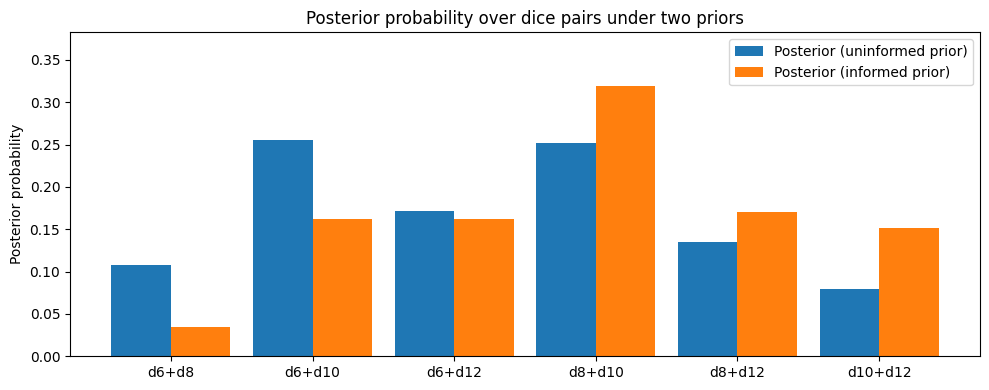

In [4]:
dice = [6, 8, 10, 12]
pairs = list(itertools.combinations(dice, 2))
labels = [f"d{a}+d{b}" for a,b in pairs]
data = [6, 12, 14, 11, 9, 10]
H0 = (8, 10)

L = {pair: likelihood(data, *pair) for pair in pairs}

# Priors
prior_uninf = {pair: 1/len(pairs) for pair in pairs}
prior_inf = {
    (6, 8): 0.05,
    (6, 10): 0.10,
    (6, 12): 0.15,
    (8, 10): 0.20,
    (8, 12): 0.20,
    (10, 12): 0.30,
}

post_uninf = posterior(prior_uninf)
post_inf = posterior(prior_inf)

pu = np.array([post_uninf[p] for p in pairs])
pi = np.array([post_inf[p] for p in pairs])

best_uninf = pairs[int(np.argmax(pu))]
best_inf = pairs[int(np.argmax(pi))]

print("Best under uninformed prior:", f"d{best_uninf[0]}+d{best_uninf[1]}", "=", pu.max())
print("Best under informed prior:  ", f"d{best_inf[0]}+d{best_inf[1]}", "=", pi.max())
print("Posterior for H0 (d8+d10) under uninformed:", post_uninf[H0])
print("Posterior for H0 (d8+d10) under informed:  ", post_inf[H0])

# Plot
x = np.arange(len(pairs))
width = 0.42

plt.figure(figsize=(10, 4))
plt.bar(x - width/2, pu, width, label="Posterior (uninformed prior)")
plt.bar(x + width/2, pi, width, label="Posterior (informed prior)")
plt.xticks(x, labels, rotation=0)
plt.ylim(0, max(pu.max(), pi.max()) * 1.2)
plt.ylabel("Posterior probability")
plt.title("Posterior probability over dice pairs under two priors")
plt.legend()
plt.tight_layout()
plt.show()
